In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import stats

In [2]:
df_stats = pd.read_csv('../Simulation/sirv_summary.csv')
df_stats.head()

,static.guid,static.age,static.ageRiskMultiplier,static.comorbidity,static.comorbidityRiskMultiplier,static.socialActivity,static.socialActivityRiskMultiplier,static.geography,static.geographyRiskMultiplier,static.mobility,...,dynamic.vaccinatedDays,dynamic.recoveredDays,dynamic.currentLocation.xcor,dynamic.currentLocation.ycor,dynamic.vaccineStatus,dynamic.proactiveVaccine,I,R,S,V
0,001f3290-1c2f-425e-ae49-bb05133fd135,0-17,0.5,False,0.5,medium,0.75,urban,1.0,independent,...,0.00,0.0,0.000000,0.000000,0.0,0.0,0.00,0.0,1.00,0.00
1,001f3290-1c2f-425e-ae49-bb05133fd135,0-17,0.5,False,0.5,medium,0.75,urban,1.0,independent,...,0.00,0.0,23.886858,21.738690,0.0,0.0,0.01,0.0,0.99,0.00
2,001f3290-1c2f-425e-ae49-bb05133fd135,0-17,0.5,False,0.5,medium,0.75,urban,1.0,independent,...,0.00,0.0,23.083588,19.537756,0.0,0.0,0.06,0.0,0.94,0.00
3,001f3290-1c2f-425e-ae49-bb05133fd135,0-17,0.5,False,0.5,medium,0.75,urban,1.0,independent,...,0.01,0.0,23.189519,20.012209,0.0,0.0,0.22,0.0,0.77,0.01
4,001f3290-1c2f-425e-ae49-bb05133fd135,0-17,0.5,False,0.5,medium,0.75,urban,1.0,independent,...,0.02,0.0,21.888587,19.741290,0.0,0.0,0.47,0.0,0.52,0.01


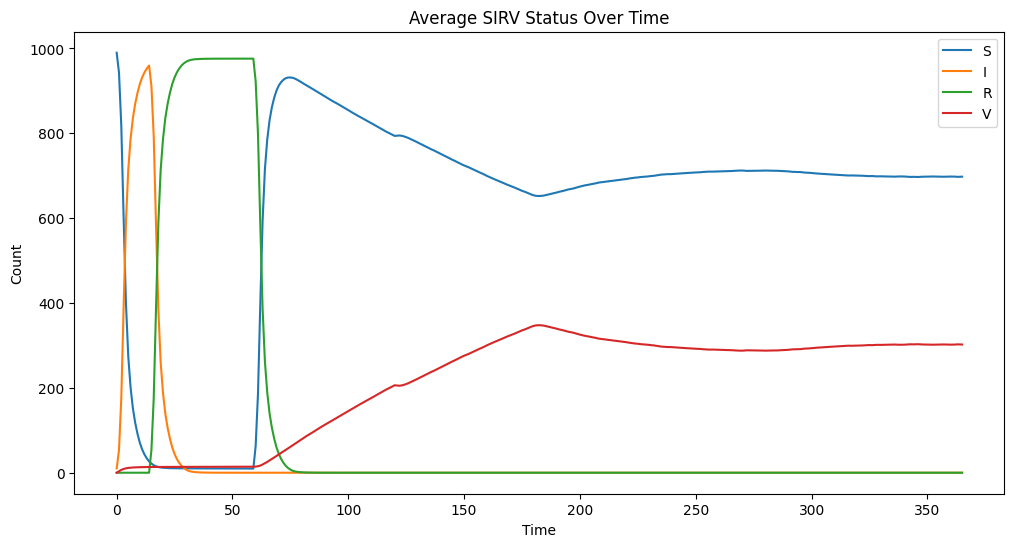

In [3]:
import plotting
plotting.plot_sirv_onehot(df_stats, title='Average SIRV Status Over Time')

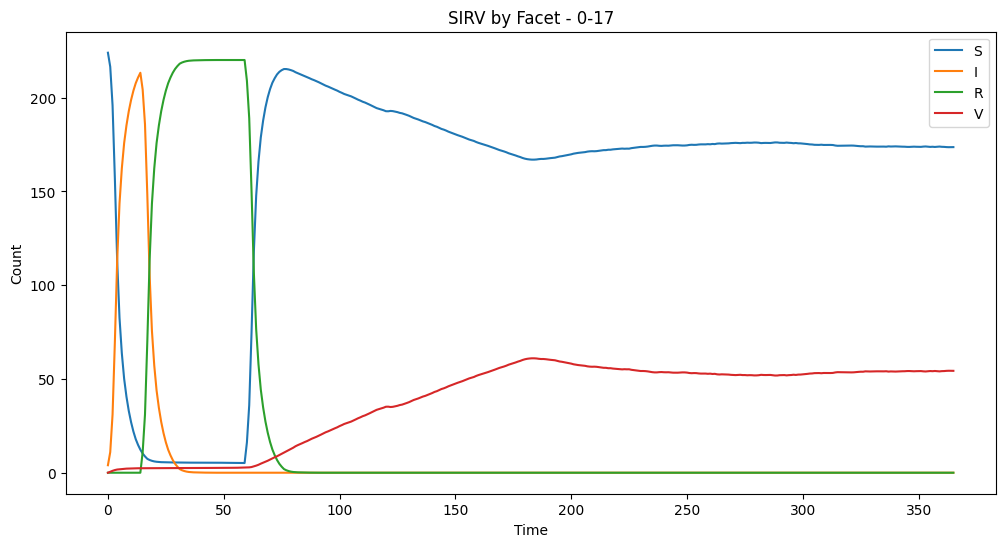

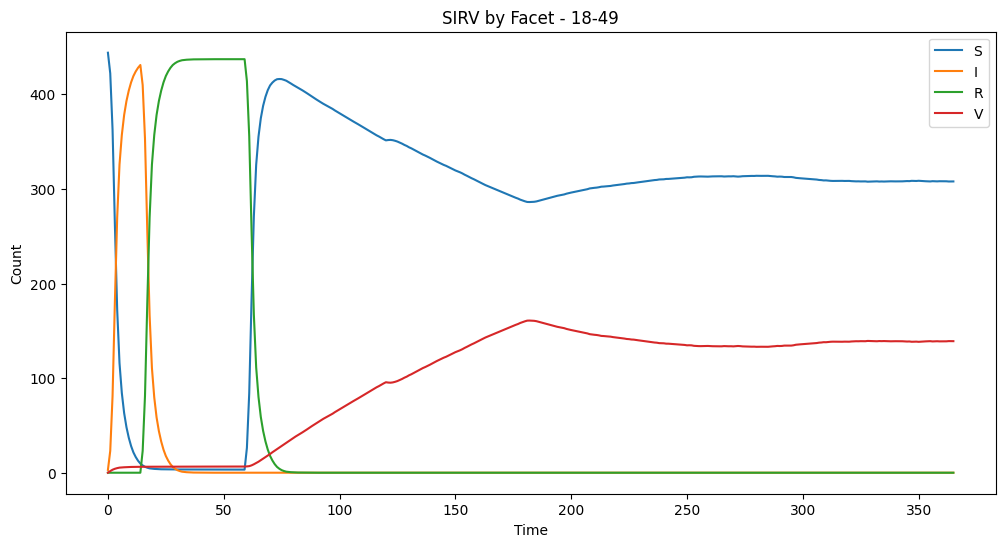

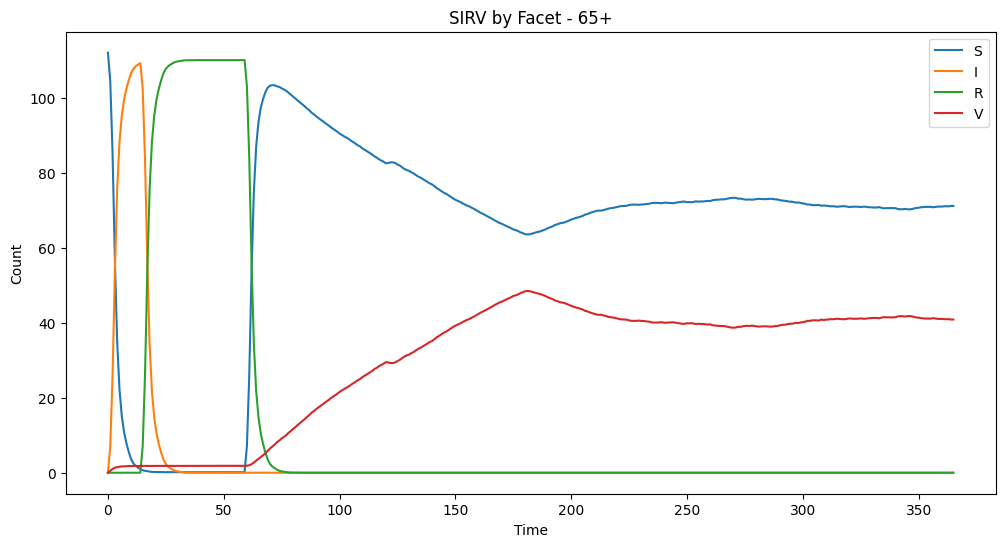

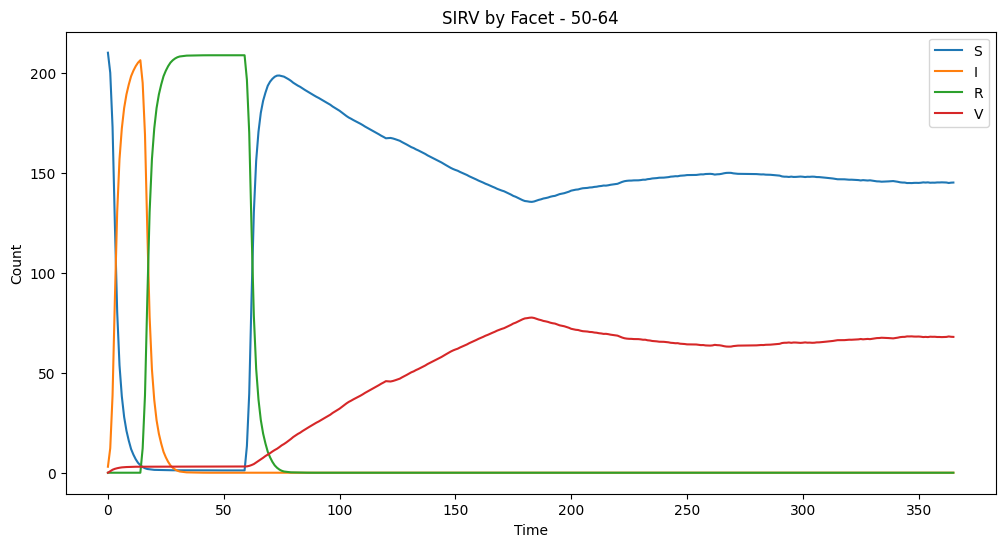

In [4]:
plotting.plot_sirv_onehot_by_facet(df_stats, facet_col='static.age')

In [5]:
r0 = stats.calculate_r0(df_stats)
print(f"Estimated R0 over free-growth window: {r0:.2f}")

Estimated R0 over free-growth window: 2.42


# Test Experimental Sweeps

In [8]:
import analysis

fast_test = {"nSim": 25, "tSpan": 365, "populationSize": 1000, "ved": 180, "sd":60, "sig": 30, "initialInfected": 1}
density_results = analysis.sweep_density([0.001, 0.005, 0.01], base_overrides = fast_test)
print("Vaccine Acceptance Sweep")
for k,v in density_results.items():
    print(f"Density = {k} particles per m^2, R0={v['r0']:.3f}, peak Re={v['re_peak']:.3f}")

Vaccine Acceptance Sweep
Density = 0.001 particles per m^2, R0=4.722, peak Re=14.000
Density = 0.005 particles per m^2, R0=4.805, peak Re=28.000
Density = 0.01 particles per m^2, R0=4.680, peak Re=14.000


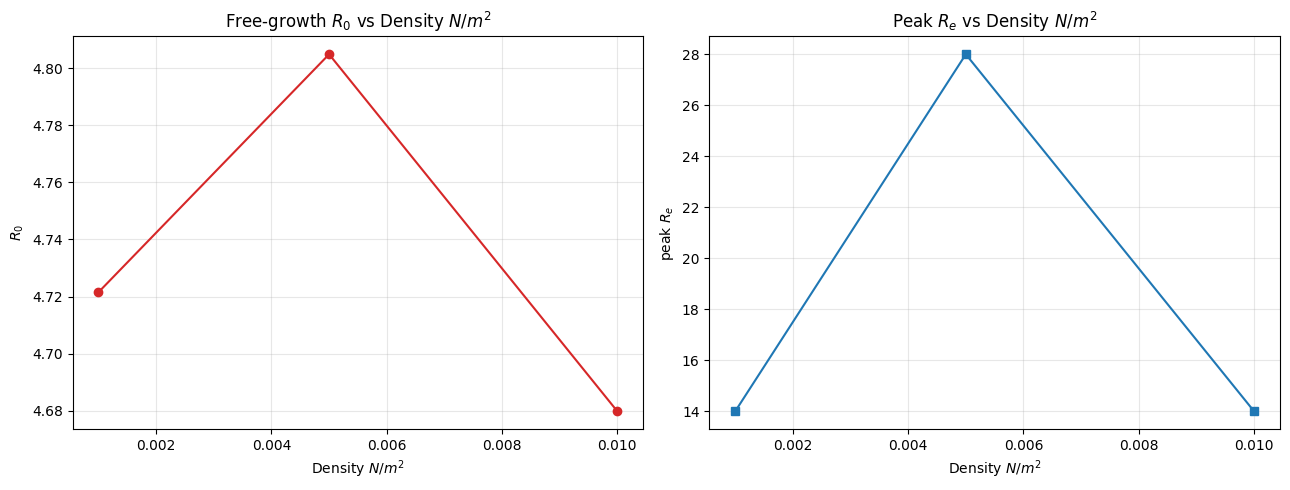

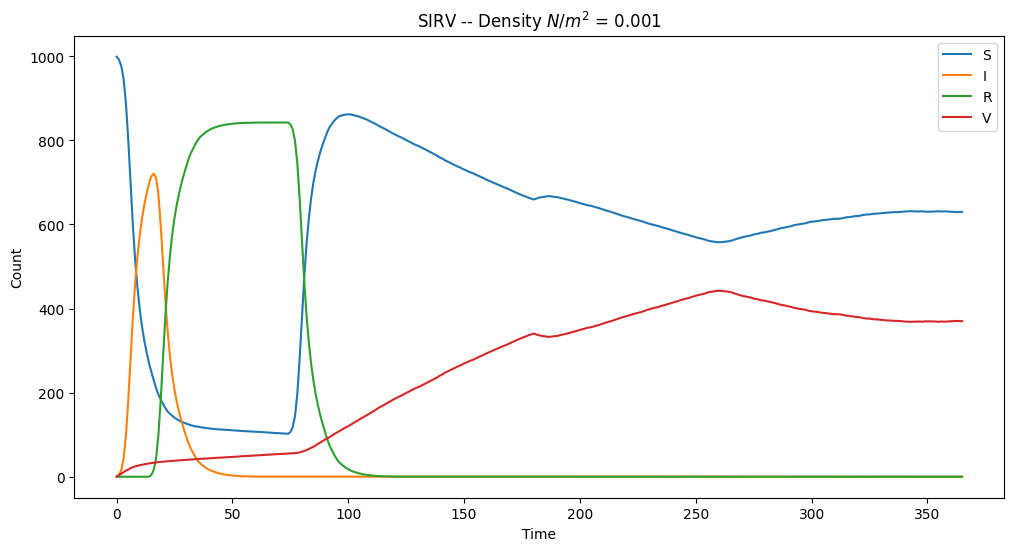

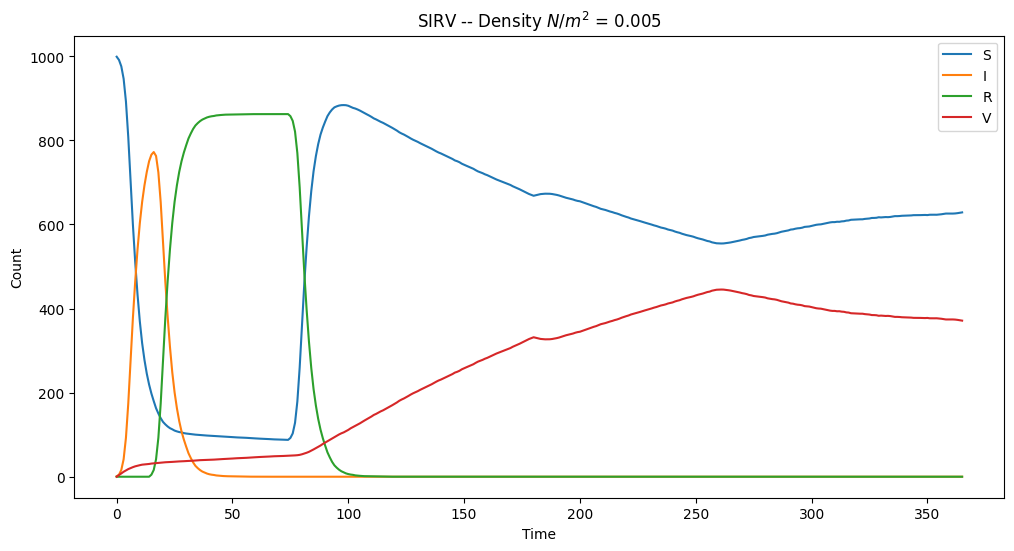

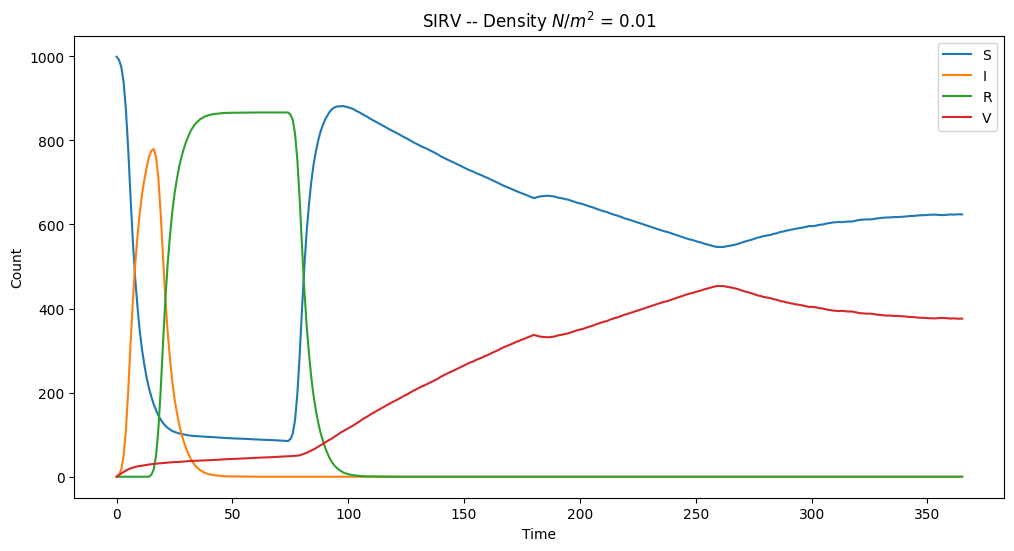

In [9]:
analysis.plot_sweep(density_results, param_label = r"Density $N/m^{2}$", plot_curves = True)

# Actual Sweeps